In [1]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()

True

In [ ]:
# llm = ChatOpenAI(model="gpt-4.1-mini")

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [6]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

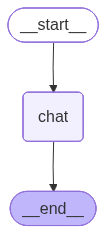

In [7]:
app

In [8]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [9]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='181d2bf9-224a-4044-9d23-642ffca663d9')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='5a3b784e2dd9a327a0d1ff95a4976ef6')]}

In [10]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [11]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [12]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [13]:
print(final_result["messages"][-1].content)

Imagine you're **blindfolded on a mountainside**, and your goal is to reach the **lowest point in the valley**.

You can't see the whole valley, only feel the ground directly beneath your feet.

How do you get to the bottom?

1.  **Feel the Slope:** You'd probably feel around to see which way is downhill – the steepest path downwards from where you are standing.
2.  **Take a Small Step:** You'd take a small step in that downhill direction.
3.  **Repeat:** You'd repeat this process: feel the slope again, take another small step, and keep doing it.

Eventually, by always moving in the direction of the steepest descent, you'd reach the bottom of the valley.

---

**Now, let's connect that to Machine Learning:**

*   **The Valley:** Represents all the possible ways your machine learning model could be set up. The "height" in the valley represents how many mistakes your model is making (its "error" or "cost").
*   **Your Goal (Lowest Point):** Is to find the settings for your model that res